Shape: (891, 15)
deck           688
age            177
embarked         2
embark_town      2
survived         0
pclass           0
sex              0
sibsp            0
parch            0
fare             0
class            0
who              0
adult_male       0
alive            0
alone            0
dtype: int64
Duplicate rows: 107
survived         int64
pclass           int64
sex             object
age            float64
sibsp            int64
parch            int64
fare           float64
embarked        object
class           object
who             object
adult_male        bool
deck            object
embark_town     object
alive           object
alone             bool
dtype: object


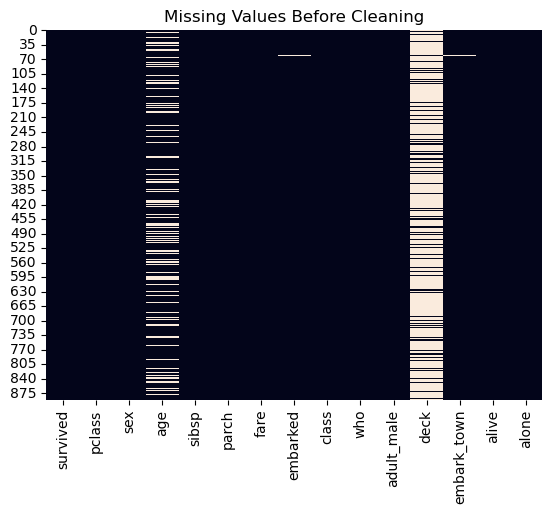

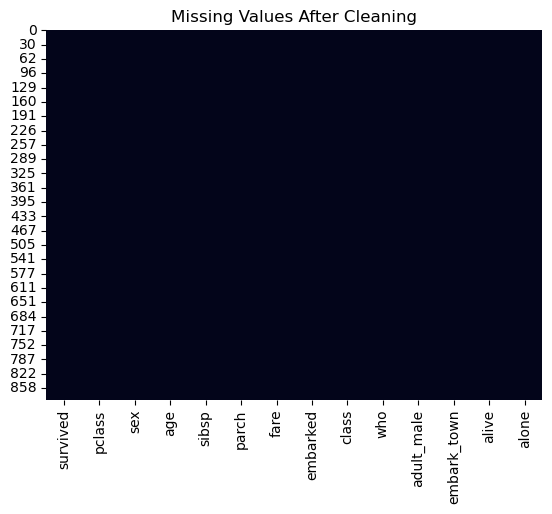

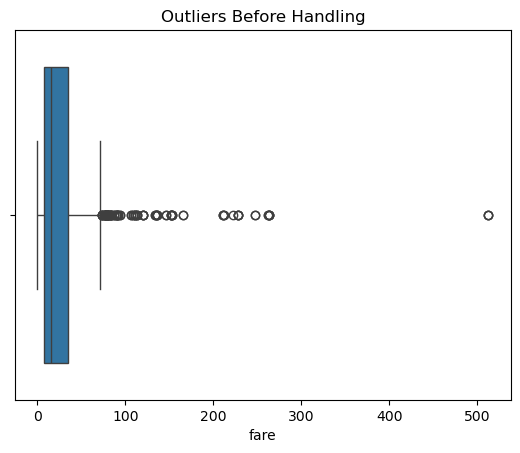

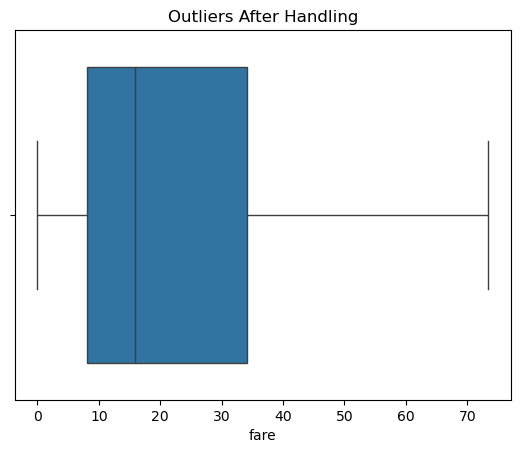

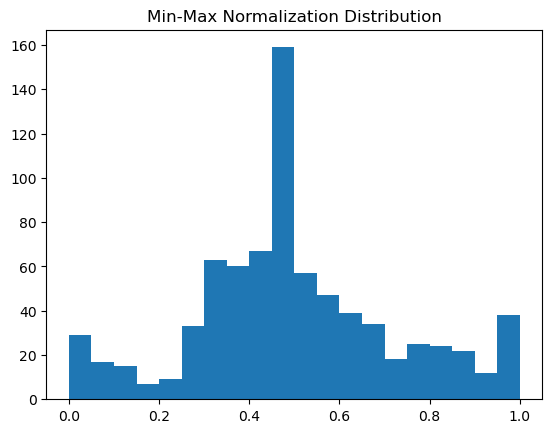

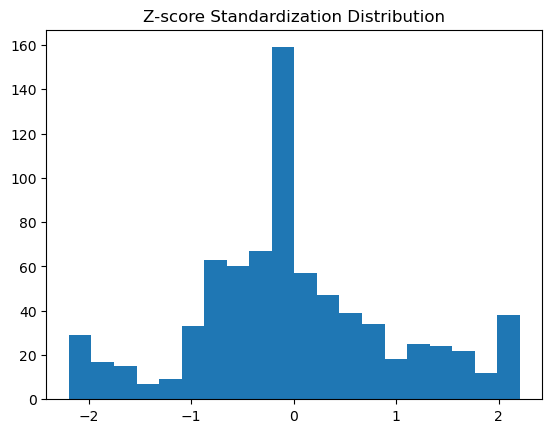

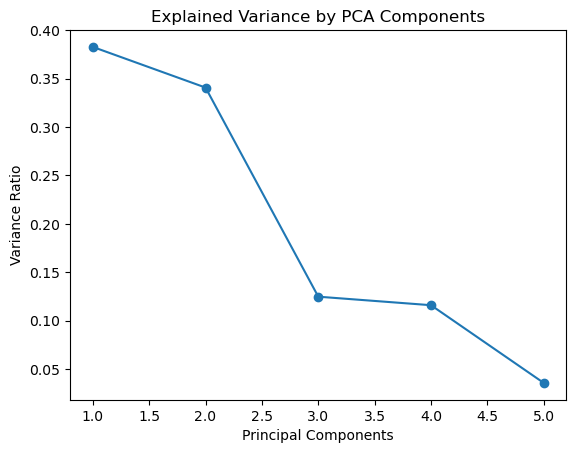

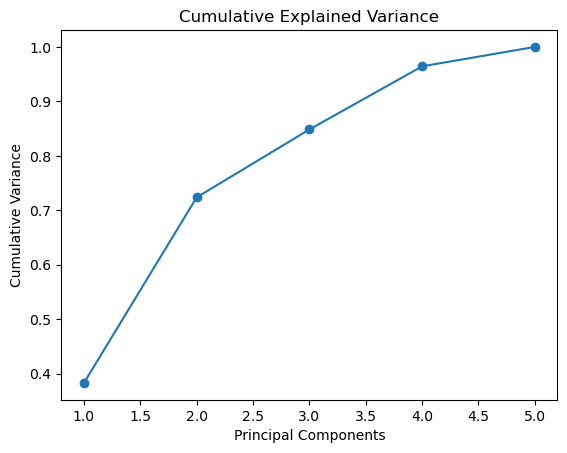

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv("titanic.csv")

print("Shape:", df.shape)
print(df.isna().sum().sort_values(ascending=False))
print("Duplicate rows:", df.duplicated().sum())
print(df.dtypes)

sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Before Cleaning")
plt.show()

if "deck" in df.columns:
    df = df.drop(columns=["deck"])

if "age" in df.columns:
    df["age"] = df["age"].fillna(df["age"].median())

if "embarked" in df.columns and df["embarked"].isna().any():
    df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

if "embark_town" in df.columns and df["embark_town"].isna().any():
    df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])

df = df.drop_duplicates()

sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values After Cleaning")
plt.show()

plt.figure()
sns.boxplot(x=df["fare"])
plt.title("Outliers Before Handling")
plt.show()

def iqr_clip(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return series.clip(lower, upper)

for col in ["age","fare","sibsp","parch"]:
    if col in df.columns:
        df[col] = iqr_clip(df[col])

plt.figure()
sns.boxplot(x=df["fare"])
plt.title("Outliers After Handling")
plt.show()

features = ["pclass","age","sibsp","parch","fare"]
X = df[features]

minmax_scaler = MinMaxScaler()
X_minmax = minmax_scaler.fit_transform(X)

plt.figure()
plt.hist(X_minmax[:,1], bins=20)
plt.title("Min-Max Normalization Distribution")
plt.show()

z_scaler = StandardScaler()
X_z = z_scaler.fit_transform(X)

plt.figure()
plt.hist(X_z[:,1], bins=20)
plt.title("Z-score Standardization Distribution")
plt.show()

pca = PCA()
pca.fit(X_z)

explained_variance = pca.explained_variance_ratio_
cumulative = np.cumsum(explained_variance)

plt.figure()
plt.plot(range(1,len(explained_variance)+1), explained_variance, marker='o')
plt.title("Explained Variance by PCA Components")
plt.xlabel("Principal Components")
plt.ylabel("Variance Ratio")
plt.show()

plt.figure()
plt.plot(range(1,len(cumulative)+1), cumulative, marker='o')
plt.title("Cumulative Explained Variance")
plt.xlabel("Principal Components")
plt.ylabel("Cumulative Variance")
plt.show()